In [ ]:
# ==========================================
# STEP 1: ENVIRONMENT SETUP & DATA LOADING
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score

# Set visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset (Assumes data.csv is uploaded to the Colab environment)
try:
    df = pd.read_csv('data.csv')
    print("Dataset loaded successfully!")
    print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
except FileNotFoundError:
    print("Please upload 'data.csv' to your Google Colab session files before running.")

Dataset loaded successfully!
Dataset Shape: 41188 rows, 21 columns



# New Section

In [ ]:
# Display the first 5 rows
print("--- FIRST 5 ROWS ---")
display(df.head())

# Display basic dataset info
print("\n--- DATASET INFO ---")
df.info()

# Check for target class distribution
print("\n--- TARGET CLASS DISTRIBUTION ---")
class_dist = df['y'].value_counts(normalize=True) * 100
print(df['y'].value_counts())
print(f"No: {class_dist['no']:.2f}%, Yes: {class_dist['yes']:.2f}%")

--- FIRST 5 ROWS ---


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



--- DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf

/tmp/ipykernel_2483/221446511.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=df, palette='Set2')


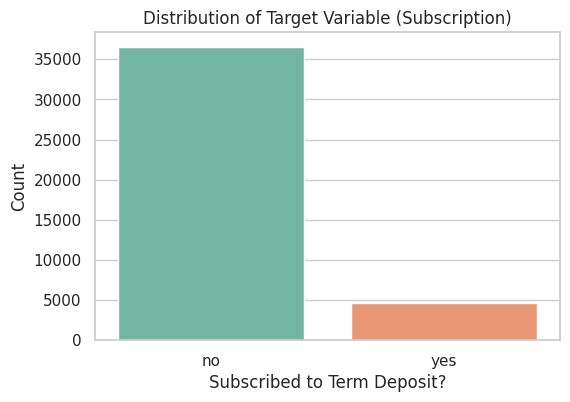

In [ ]:
# Plotting the target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, palette='Set2')
plt.title('Distribution of Target Variable (Subscription)')
plt.xlabel('Subscribed to Term Deposit?')
plt.ylabel('Count')
plt.show()

In [ ]:
# Check for 'unknown' placeholders in categorical variables
print("--- UNKNOWN VALUES PER CATEGORICAL COLUMN ---")
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} counts ({unknown_count/len(df)*100:.2f}%)")

--- UNKNOWN VALUES PER CATEGORICAL COLUMN ---
job: 330 counts (0.80%)
marital: 80 counts (0.19%)
education: 1731 counts (4.20%)
default: 8597 counts (20.87%)
housing: 990 counts (2.40%)
loan: 990 counts (2.40%)


In [ ]:
# Separating features (X) and target (y)
X = df.drop(columns=['y'])
y = df['y'].apply(lambda x: 1 if x == 'yes' else 0) # Convert target to binary 0 and 1

# Identify column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features ({len(num_cols)}): {num_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

# Build Preprocessing Transformers
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', drop='first')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# Perform stratified train-test split to preserve the target class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Numerical features (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Training set size: 32950
Testing set size: 8238


In [ ]:
# 1. Define Logistic Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# 2. Define Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=150, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1))
])

# Train models
print("Training Logistic Regression Model...")
lr_pipeline.fit(X_train, y_train)

print("Training Random Forest Model...")
rf_pipeline.fit(X_train, y_train)

print("Model training completed successfully!")

Training Logistic Regression Model...
Training Random Forest Model...
Model training completed successfully!


In [ ]:
# Predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("==================================================")
print("          LOGISTIC REGRESSION PERFORMANCE         ")
print("==================================================")
print(classification_report(y_test, y_pred_lr))

print("==================================================")
print("            RANDOM FOREST PERFORMANCE             ")
print("==================================================")
print(classification_report(y_test, y_pred_rf))

          LOGISTIC REGRESSION PERFORMANCE         
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7310
           1       0.45      0.91      0.60       928

    accuracy                           0.87      8238
   macro avg       0.72      0.89      0.76      8238
weighted avg       0.93      0.87      0.88      8238

            RANDOM FOREST PERFORMANCE             
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      7310
           1       0.49      0.91      0.64       928

    accuracy                           0.88      8238
   macro avg       0.74      0.89      0.78      8238
weighted avg       0.93      0.88      0.90      8238



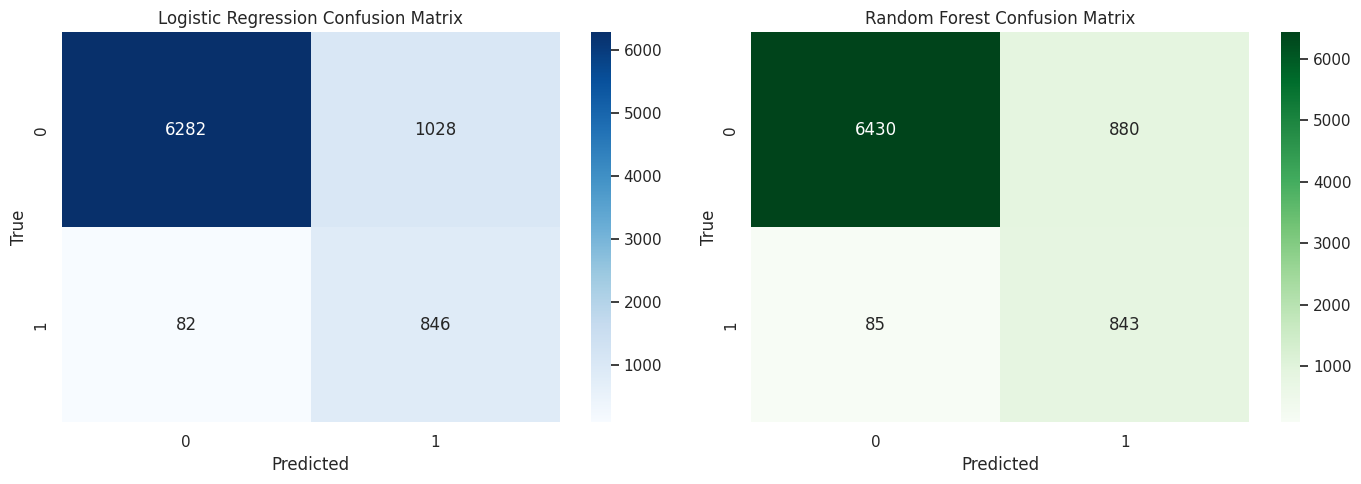

In [ ]:
# Plot Confusion Matrices side by side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Logistic Regression Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('True')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Random Forest Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('True')

plt.tight_layout()
plt.show()

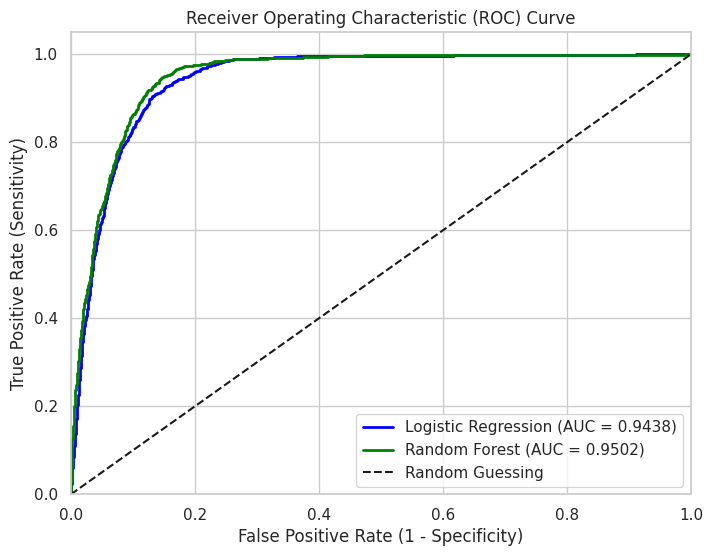

In [ ]:
# Compute ROC-AUC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Plot ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', color='blue', lw=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', color='green', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

/tmp/ipykernel_2483/2459101782.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(all_features)[indices], palette='viridis')


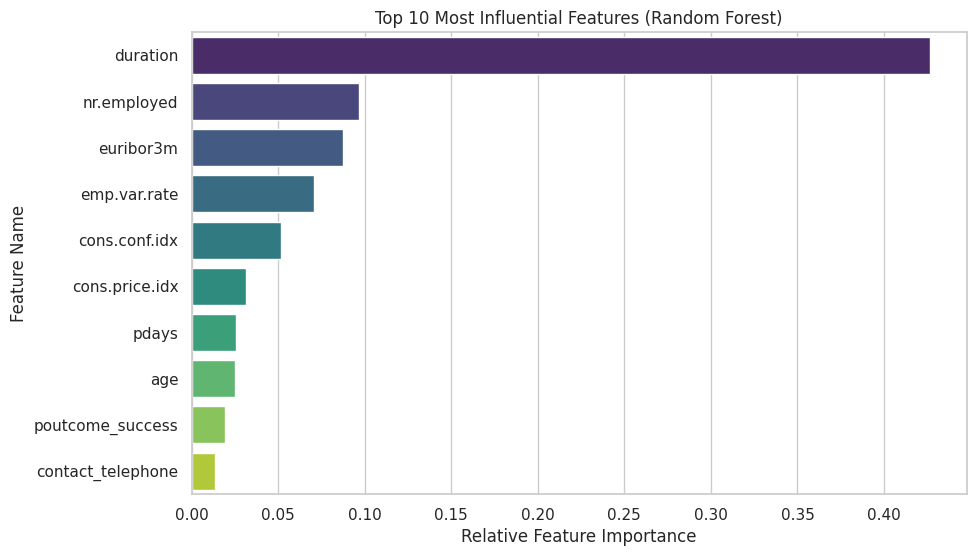

In [ ]:
# Extra Credit: Feature Importance Exploration from Random Forest
# Extract feature names after OneHotEncoding transformation
encoded_cat_features = rf_pipeline.named_steps['preprocessor']\
                       .named_transformers_['cat']\
                       .get_feature_names_out(cat_cols).tolist()
all_features = num_cols + encoded_cat_features

importances = rf_pipeline.named_steps['classifier'].feature_importances_
indices = np.argsort(importances)[::-1][:10] # Select top 10 features

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=np.array(all_features)[indices], palette='viridis')
plt.title('Top 10 Most Influential Features (Random Forest)')
plt.xlabel('Relative Feature Importance')
plt.ylabel('Feature Name')
plt.show()